# Nitrite-driven photoautotrophy

Nitrite as the electron donor for photosynthetic CO₂ fixation. The
hardest of the three: nitrate/nitrite sits at +0.407 V, so the pull
against CO₂ is the longest.

The pattern is the same in all three of the `photo*` notebooks: build the
CO₂-fixation reaction, confirm it does **not** pay in the dark, then add the
energy of absorbed photons and see what it takes to close the gap.

Two conventions to keep straight:

* A couple is always written **(reduced, oxidized)**. So the CO₂/biomass
  acceptor is `Couple.make("Biomass", "CO2")` — biomass is the reduced form.
  Writing it the other way round still gives the right energy, because the
  direction comes from which couple is the donor and which the acceptor, but
  it swaps the `reduced`/`oxidized` labels and the oxidation-state
  annotations.
* The reaction direction is CO₂ fixation because `acceptor=` is the couple
  being reduced. Nothing else needs doing to get that direction.

In [1]:
import matplotlib.pyplot as plt

import microbial_thermo as mt
from microbial_thermo.figures import (
    light_budget_table,
    plot_energy_explorer,
    plot_light_budget,
    plot_redox_tower,
)
from microbial_thermo.photons import photon_energy, photons_required
from microbial_thermo.reaction import Couple, Reaction
from microbial_thermo.sweep import concentration_axis, partial_pressure_axis, ph_axis

conditions = mt.Conditions(temperature_c=25.0, pH=7)

## The biomass placeholder

`<CH2O>` is cell carbon at oxidation state zero, and it is a **placeholder**,
not a measured compound — it lives in the hand-entered supplemental table and
warns on every use. Its value is this library's glucose divided by six, so
writing the acceptor as `glucose` instead gives the same energy per carbon.

In [2]:
from microbial_thermo.supplemental import supplemental_species

supplemental_species()["Biomass(aq)"]

SupplementalSpecies(backend='Biomass(aq)', formula='CH2O', delta_Gf_kJ_mol=-152.9, temperature_c=25.0, delta_Hf_kJ_mol=None, display='\\langle CH_2O\\rangle', phase='aq', smiles=None, aliases=('biomass', 'CH2O', '<CH2O>', 'cells', 'cell carbon'), verified=False, provenance="A PLACEHOLDER, not a measured compound. Biomass has no formation energy in the sense the rest of this file does: <CH2O> is a stand-in for cell carbon at oxidation state zero, and the value here is this library's own aqueous glucose divided by six (-917.2 / 6 = -152.87), so the two are at least mutually consistent. It therefore inherits glucose's unverified status as well as its own. Two things it gets wrong on purpose. Real biomass is nearer CH1.8O0.5N0.2 -- slightly more reduced than CH2O, so a little more costly to make -- and it contains nitrogen, so this term omits the cost of assimilating N entirely. Treat any autotrophy yield built on it as an order-of-magnitude statement about sign and scale, not a number to 

## The reaction

NO₂⁻ → NO₃⁻ is a two-electron step at +0.407 V at pH 7 — a much
weaker donor than either arsenite or Fe(II).

In [3]:
reaction = Reaction.from_couples(
    donor=Couple.make("Nitrite", "Nitrate"),
    acceptor=Couple.make("Biomass", "CO2"),
    conditions=conditions,
)
print(reaction.summary())

Reaction:  NO2- + 1/2 H2O + 1/2 CO2(aq) -> NO3- + 1/2 Biomass(aq)
  donor     NO3-/NO2-  (oxidative)  E0' = +0.407 V
  acceptor  CO2(aq)/Biomass(aq)  (reductive)  E0' = -0.403 V
  n electrons        2
  dE0'               -0.811 V
  dG0'               +156.4 kJ/mol
  dG (conditions)    +156.4 kJ/mol
  dG per electron    +78.2 kJ/mol e-


/home/jamesrh/Desktop/Current/Topics in Microbial Physiology and Biogeochemistry course/thermodynamic problems/microbial_thermo/backends/pygcc_backend.py:234: UserWarning: Biomass(aq) uses a hand-entered formation energy that has not been traced to a primary source (A PLACEHOLDER, not a measured compound. Biomass has no formation energy in the sense the rest of this file does: <CH2O> is a stand-in for cell carbon at oxidation state zero, and the value here is this library's own aqueous glucose divided by six (-917.2 / 6 = -152.87), so the two are at least mutually consistent. It therefore inherits glucose's unverified status as well as its own. Two things it gets wrong on purpose. Real biomass is nearer CH1.8O0.5N0.2 -- slightly more reduced than CH2O, so a little more costly to make -- and it contains nitrogen, so this term omits the cost of assimilating N entirely. Treat any autotrophy yield built on it as an order-of-magnitude statement about sign and scale, not a number to quote. V

## It does not pay in the dark

A positive ΔG is the whole point — this is the reaction a phototroph needs
light for.

In [4]:
energy = reaction.delta_G_standard_prime
print(f"dG0' = {energy.magnitude:+.1f} kJ/mol per {reaction.n_electrons} e-")
print(f"uphill: {energy.magnitude > 0}")

dG0' = +156.4 kJ/mol per 2 e-
uphill: True


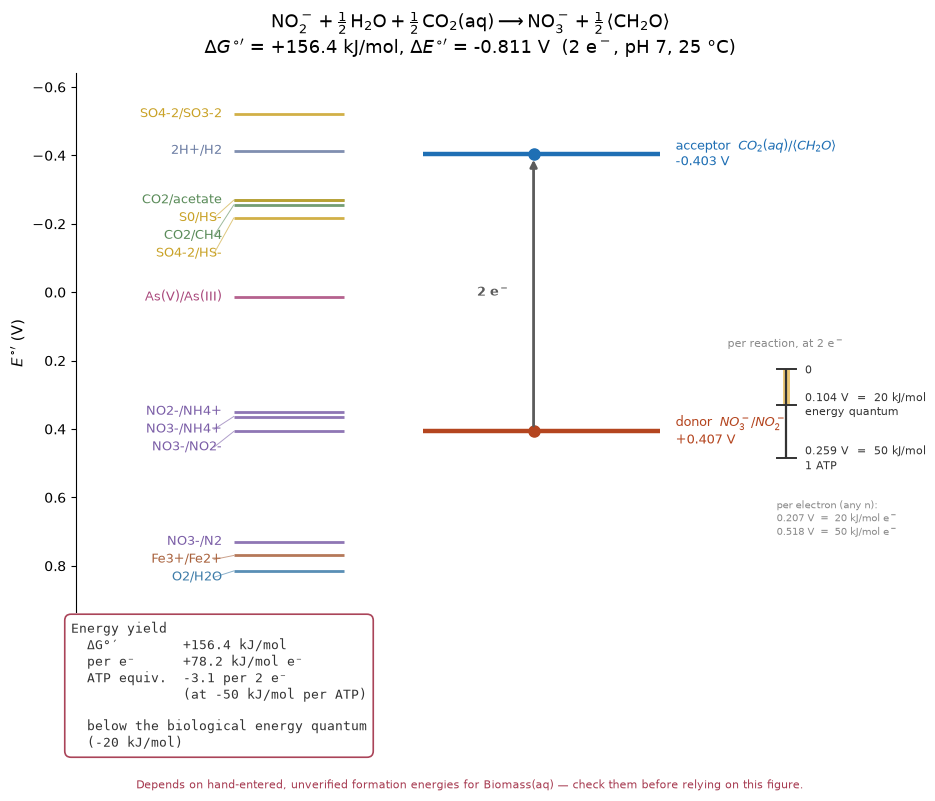

In [5]:
plot_redox_tower(reaction)
plt.show()

## Which species the explorer should sweep

Take them straight off the reaction rather than naming the couples one at a
time. Every species carrying a coefficient is a candidate; three are worth
dropping:

* **H⁺** because that is pH, and pH gets its own axis below — sweeping it as
  a concentration as well would plot the same variable twice.
* **H₂O** because it is the solvent, held at unit activity.
* **e⁻** because it never survives into a balanced full reaction, so this is
  only defensive.

Reading it off `reaction.coefficients` also survives a couple whose side
names several species, which naming `couple.reduced` and `couple.oxidized`
by hand does not. (Note `Couple` itself has no `.backend` — the backend name
lives on the `Species`, at `couple.oxidized.backend`.)

In [6]:
Elist = [
    s.backend for s in reaction.coefficients if s.backend not in ("H+", "H2O", "e-")
]
Elist

['NO3-', 'NO2-', 'CO2(aq)', 'Biomass(aq)']

Then pH, plus one axis per species. Two details worth branching on, which is
what `sweep.default_axes` does internally:

* A **solid** sits at unit activity, so a concentration axis for one is a
  flat line. `Fe(OH)3` in the iron notebook is exactly that case — it would
  give the dropdown an entry that does nothing.
* A **gas** takes a partial pressure rather than a concentration.

In [7]:
axes = [ph_axis(low=0.0, high=14.0, n=29)]
for species in reaction.coefficients:
    if species.backend not in Elist:
        continue
    if species.is_gas:
        axes.append(partial_pressure_axis(species.backend, n=13))
    elif species.is_aqueous:
        axes.append(concentration_axis(species.backend, n=13))

print(f"{len(axes)} axes: " + ", ".join(a.label for a in axes))

5 axes: pH, [NO3-] (molal), [NO2-] (molal), [CO2(aq)] (molal), [Biomass(aq)] (molal)


In [8]:
figure = plot_energy_explorer(reaction, axes=axes)
figure.show()

/home/jamesrh/Desktop/Current/Topics in Microbial Physiology and Biogeochemistry course/thermodynamic problems/microbial_thermo/reaction.py:221: UserWarning: pH 7 is within 1 unit of a pKa for the carbonate family (pKa 6.34, 10.33); HCO3- holds only 82% of the total. Give a total concentration via total_concentrations={'carbonate': ...} so the speciation is handled for you.
  activity = _activity(species, conditions, backend)


## Adding the energy from phototrophy

A mole of photons carries $N_A hc/\lambda$. Purple bacteria use
bacteriochlorophyll *a*, absorbing near 870 nm, which is 137.5 kJ/mol.

In [9]:
print(f"P870 photon: {photon_energy('P870').magnitude:.1f} kJ/mol")
print(f"photons needed here: {photons_required(energy):.2f}")

P870 photon: 137.5 kJ/mol
photons needed here: 1.28


`photons_required` asks how many photons' worth of energy the reaction is
short by, measured down to the biological energy quantum rather than to
zero. It is a **floor**, not a quantum requirement: real anoxygenic
phototrophs run cyclic electron flow and reverse electron transport and
spend several photons per electron.

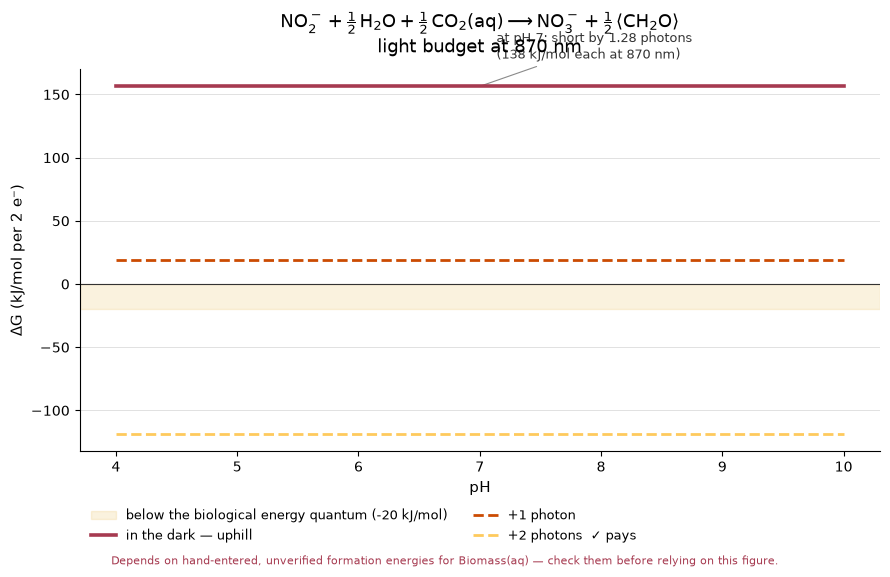

In [10]:
plot_light_budget(reaction)
plt.show()

## All three donors side by side

In [11]:
others = {
    "photoarsenotrophy": Couple.make("As(III)", "As(V)"),
    "photoferrotrophy": Couple.make("Fe++", "Fe(OH)3", key_element="Fe"),
    "nitrite photoautotrophy": Couple.make("Nitrite", "Nitrate"),
}
built = {
    name: Reaction.from_couples(
        donor=couple, acceptor=Couple.make("Biomass", "CO2"), conditions=conditions
    )
    for name, couple in others.items()
}
light_budget_table(built)

,reaction,dG0' (kJ/mol),photons needed,kJ/mol per photon
0,photoarsenotrophy,80.310510,0.729521,137.5018
1,photoferrotrophy,51.219959,0.517957,137.5018
2,nitrite photoautotrophy,156.437716,1.283167,137.5018


This one needs 1.28 photons' worth at pH 7, so a single 870 nm photon
per electron pair does *not* cover it. That is the sharpest contrast
among the three donors.